# Does Descriptive Content Predict Semantic Shift Trajectory?

## Introduction 

Hamilton et al.'s 2016 paper Cultural Shift or Linguistic Drift? posits nouns are more likely to undergo irregular cultural shifts compared to other parts of speech, specifically adverbs, which are more likely to bleach through sense extension (Sweetser-style). 

However, I believe that descriptive content is a better predictor than POS. Nouns with high descriptive content have specific, entrenched meanings, making them more resistant to Sweetser-style shifts over time. This effect would be especially strong in proper nouns. Nouns with weak descriptive content could still undergo irregular cultural shifts, but may be less resistant to gradual extension. 

In [2]:

from driftcache import Space
import numpy as np

VECTORS = "./vectors/5sub/sgns.words"
VOCAB = "./vectors/5sub/counts.words.vocab"
YEARS = range(2012, 2019)

sp = Space(VECTORS, k=50)

In [3]:
counts = sp.counts(VOCAB)

## Measuring Descriptive Content

There are several ways to measure or approximate descriptive content in the literature. [Brysbaert et al.](https://link.springer.com/article/10.3758/s13428-013-0403-5) offers concreteness ratings for 40,000 English words, which were used as a baseline. Their ratings assign hard-to-visualize words (like "glory") low rankings, and easily imaginable words (like "banana") higher ratings. 

The other potential metric was polysemy. While polysemous words do not inherently entail lower descriptive content, they do potentially impact how easy it is to visualize words (the many sense of bank, for example).

The block with both of these metrics is coverage; polysemy is best estimated from dictionary entries, through either WordNet or Wikitionary, but both offer poor coverage of slang vocabulary. The same confound impacts Brysbaert's concreteness ratings. 

In [4]:
class _Neighbors: 
    def __init__(self, sp, year):
        self._sp, self._y = sp, year
        
    def __getitem__(self, word):
        return self._sp.neighbors(self._y, word)
    
    def __contains(self, word):
        return word in self._sp.index[self._y]
    
    def keys(self):
        return iter(self._sp.words[self._y])
    
    def items(self):
        for w in self._sp.words[self._y]:
            yield w, self._sp.neighbors(self._y, w)
            
nearest_neighbors = {y: _Neighbors(sp, y) for y in YEARS}

In [5]:
print(nearest_neighbors[2012]["thor"])

[('loki', 0.8316612839698792), ('superman', 0.8301238417625427), ('batman', 0.8014139533042908), ('lotr', 0.7761991620063782), ('hulk', 0.7756953239440918), ('avengers', 0.7624371647834778), ('bruce', 0.7605069875717163), ('deadpool', 0.748565673828125), ('aang', 0.7437412142753601), ('vader', 0.7429584264755249), ('star', 0.7397899627685547), ('darth', 0.7379311323165894), ('odin', 0.7346312999725342), ('wolverine', 0.7303524613380432), ('hawkeye', 0.7300650477409363), ('harry', 0.7295538187026978), ('frodo', 0.7223544716835022), ('trek', 0.7137396931648254), ('zeus', 0.7133501172065735), ('marvel', 0.7114070057868958), ('snape', 0.7083191275596619), ('cameron', 0.7071203589439392), ('skywalker', 0.702198326587677), ('spiderman', 0.7012900114059448), ('anakin', 0.6975599527359009), ('james', 0.6974152326583862), ('trilogy', 0.6973206996917725), ('tony', 0.6963030099868774), ('potter', 0.6961206197738647), ('gandalf', 0.6914930939674377), ('hobbit', 0.6911484003067017), ('rpg', 0.68865

In [6]:
print(nearest_neighbors[2018]["thor"])

[('ragnarok', 0.8854701519012451), ('gotg', 0.7631475329399109), ('avengers', 0.7491826415061951), ('terminator', 0.7397520542144775), ('kylo', 0.7337888479232788), ('loki', 0.7316206097602844), ('spiderman', 0.7250843048095703), ('hannibal', 0.7242490649223328), ('superman', 0.7235959768295288), ('marvel', 0.7220394611358643), ('deadpool', 0.7178364396095276), ('trilogy', 0.7166725397109985), ('hulk', 0.7113019824028015), ('interstellar', 0.7087157368659973), ('spider', 0.7048578262329102), ('wolverine', 0.703166127204895), ('jurassic', 0.6999044418334961), ('panther', 0.6983519196510315), ('pixar', 0.6982516646385193), ('parker', 0.6978833079338074), ('mcu', 0.6917785406112671), ('lotr', 0.6899557709693909), ('raider', 0.6895468831062317), ('transformers', 0.6886379718780518), ('trek', 0.6840839982032776), ('hercules', 0.6819671392440796), ('pratt', 0.6813874244689941), ('tlj', 0.6809672117233276), ('daredevil', 0.6800401210784912), ('samurai', 0.6793689131736755), ('superhero', 0.67

In [7]:
tn = sp.tn

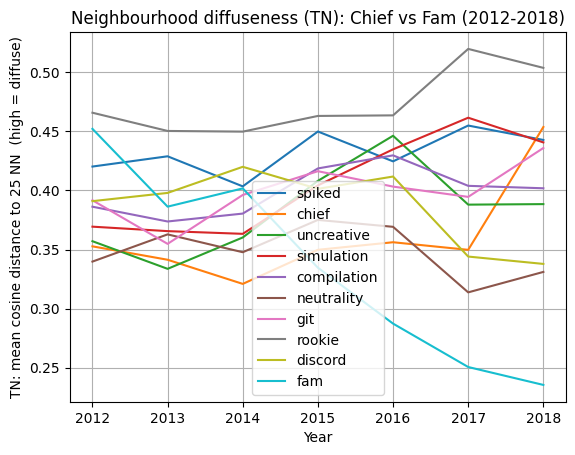

In [8]:
import matplotlib.pyplot as plt

candidates = ["spiked", "chief", "uncreative", "simulation", "compilation",
              "neutrality", "git", "rookie", "discord", "fam"]

for candidate in candidates:
    plt.plot(YEARS, [tn[y][candidate] for y in YEARS], label=candidate)
    
    
plt.xlabel('Year')
plt.ylabel('TN: mean cosine distance to 25 NN  (high = diffuse)')
plt.title('Neighbourhood diffuseness (TN): Chief vs Fam (2012-2018)')
plt.legend()
plt.grid(True)
plt.show()

One big caveat with descriptive content is that it doesn't stay stable across all the years; while change is theoretically possible, anchoring on a different year can affect the trend. I used 2014, which has the strongest correlation with Bysbaert's ratings. 2012, the first year of the corpus, would be the natural other anchor, but the 2012 slice is very thin. 

In [9]:
import plotly.express as px

drift_words, ys = sp.drift(2012, 2018, metric="cosine") 
xs = [tn[2014][w] if w in tn[2014] else None for w in drift_words]


fig = px.scatter(x=xs, y=ys, hover_name = drift_words, opacity=0.5, labels={'x':'TN (2014)', 'y':'Cosine similarity (2012 vs 2018)'})

fig.update_traces(marker=dict(size=4,opacity=0.5),
                  selector=dict(mode='markers'))

fig.show()

There isn't an obvious relationship between cosine similarity and TN; most of the words with diffuse meaning and low cosine similarity are typos, while those with high cosine and low TN are rare words that probably have poorly estimated neighborhoods. "An" appears to have the highest TN score and highest cosine similarity, which is a decent validation of the measure. 

We can validate the geometric approximation against Brysbaert et al.'s ratings:

In [10]:
import pandas as pd

brysbaert = pd.read_csv("./data/brysbaert_concreteness.txt", sep="\t")

brysbaert.set_index("Word", inplace=True)

brysbaert.head()

,Bigram,Conc.M,Conc.SD,Unknown,Total,Percent_known,SUBTLEX,Dom_Pos
Word,,,,,,,,
roadsweeper,0,4.85,0.37,1,27,0.96,0,0
traindriver,0,4.54,0.71,3,29,0.90,0,0
tush,0,4.45,1.01,3,25,0.88,66,0
hairdress,0,3.93,1.28,0,29,1.00,1,0
pharmaceutics,0,3.77,1.41,4,26,0.85,0,0


In [11]:
xs, ys = [brysbaert.loc[word]["Conc.M"] for word in drift_words if word in brysbaert.index and word in tn[2014]], [tn[2014][word] for word in drift_words if word in brysbaert.index and word in tn[2014]]

print(len(xs)/len(drift_words)*100)

34.93612466463711


While Brysbaert provides high-quality ratings, the coverage is poor for Reddit specifically; 34.9% of the corpus is covered. 

In [12]:
from scipy.stats import spearmanr

print(spearmanr(xs, ys))

SignificanceResult(statistic=np.float64(-0.28995825927384594), pvalue=np.float64(0.0))


Overall, the correlation is decent ($\rho = -0.29$). However, better concreteness ratings can be built out using a regression model on the vectors themselves. 

In [13]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split

bysbaert_corpus_overlap = [word if word in brysbaert.index and word in sp.index[2014] else None for word in drift_words]

X = [sp.mat[2014][sp.index[2014][word]] for word in bysbaert_corpus_overlap if word is not None]
Y = [brysbaert.loc[word]["Conc.M"] for word in bysbaert_corpus_overlap if word is not None]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
model = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=10)
model.fit(X_train, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",array([1.0000...00000000e+03])
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : same as 'eigen' 'svd' : use singular value decomposition of X when X is dense, fallback to 'eigen' when X is sparse 'eigen' : use eigendecomposition of X X' when n_samples <= n_features or X' X when n_features < n_samplesThe 'auto' mode is the default and is intended to pick the cheaperoption depending on the shape and sparsity of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets.This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionadded:: 0.24",False
Name,Type,Value
"alpha_ alpha_: float or ndarray of shape (n_targets,)Estimated regularization parameter, or, if ``alpha_per_target=True``,the estimated regularization parameter for each target.",float64,1
"best_score_ best_score_: float or ndarray of shape (n_targets,)Score of base estimator with best alpha, or, if``alpha_per_target=True``, a score for each target... versionadded:: 0.23",float64,0.6584
"coef_ coef_: ndarray of shape (n_features) or (n_targets, n_features)Weight vector(s).","ndarray[float64](100,)","[-0.47,-0.07,-0.24,..., 0.82,-0.17,-0.82]"


In [15]:
model.score(X_test, y_test)

0.6447427645312331

In [16]:
print(spearmanr(y_test, model.predict(X_test)))

SignificanceResult(statistic=np.float64(0.8042730307287732), pvalue=np.float64(0.0))


$R^2\approx0.64$ ($|\rho| = 0.81$) is substantially better than the $|\rho| = 0.29$ from TN

In [17]:
model.fit(X, Y)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",array([1.0000...00000000e+03])
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : same as 'eigen' 'svd' : use singular value decomposition of X when X is dense, fallback to 'eigen' when X is sparse 'eigen' : use eigendecomposition of X X' when n_samples <= n_features or X' X when n_features < n_samplesThe 'auto' mode is the default and is intended to pick the cheaperoption depending on the shape and sparsity of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets.This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionadded:: 0.24",False
Name,Type,Value
"alpha_ alpha_: float or ndarray of shape (n_targets,)Estimated regularization parameter, or, if ``alpha_per_target=True``,the estimated regularization parameter for each target.",float64,3.162
"best_score_ best_score_: float or ndarray of shape (n_targets,)Score of base estimator with best alpha, or, if``alpha_per_target=True``, a score for each target... versionadded:: 0.23",float64,0.6465
"coef_ coef_: ndarray of shape (n_features) or (n_targets, n_features)Weight vector(s).","ndarray[float64](100,)","[-0.46,-0.09,-0.25,..., 0.82,-0.15,-0.84

In [18]:
imputed_concreteness = {word: model.predict(sp.mat[2014][sp.index[2014][word]].reshape(1, -1)) for word in sp.words[2014]}

Now we have concreteness ratings that cover the entirety of the corpus. 

In [19]:
top_5_truth = sorted({word: brysbaert.loc[word]["Conc.M"] for word in drift_words if word in brysbaert.index}.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 words with highest actual concreteness in 2014:")
for word, concreteness in top_5_truth:
    print(f"Actual: {word}: {concreteness}. Predicted: {imputed_concreteness[word]}") 

print("\nTop 5 words with lowest actual concreteness in 2014:")
bottom_5_truth = sorted({word: brysbaert.loc[word]["Conc.M"] for word in drift_words if word in brysbaert.index}.items(), key=lambda x: x[1])[:5]
for word, concreteness in bottom_5_truth:
    print(f"Actual: {word}: {concreteness}. Predicted: {imputed_concreteness[word]}")


Top 5 words with highest actual concreteness in 2014:
Actual: house: 5.0. Predicted: [4.48079549]
Actual: bed: 5.0. Predicted: [4.38084765]
Actual: baby: 5.0. Predicted: [4.65833286]
Actual: water: 5.0. Predicted: [4.55428473]
Actual: tv: 5.0. Predicted: [3.99598806]

Top 5 words with lowest actual concreteness in 2014:
Actual: eh: 1.04. Predicted: [3.00867177]
Actual: although: 1.07. Predicted: [1.78458771]
Actual: spirituality: 1.07. Predicted: [2.23312162]
Actual: would: 1.12. Predicted: [2.01205328]
Actual: spiritually: 1.14. Predicted: [2.03251162]


In [20]:
top_5 = sorted(imputed_concreteness.items(), key=lambda x: x[1], reverse=True)[:5]
bottom_5 = sorted(imputed_concreteness.items(), key=lambda x: x[1])[:5]

print("\nPredicted top 5 words with highest predicted concreteness in 2014:")
for word, concreteness in top_5:
    print(f"Predicted: {word} {concreteness} Actual: {brysbaert.loc[word]['Conc.M'] if word in brysbaert.index else 'N/A'}")

print("\nPredicted bottom 5 words with lowest predicted concreteness in 2014:")
for word, concreteness in bottom_5:
    print(f"Predicted: {word} {concreteness} Actual: {brysbaert.loc[word]['Conc.M'] if word in brysbaert.index else 'N/A'}")


Predicted top 5 words with highest predicted concreteness in 2014:
Predicted: shoe [5.50942113] Actual: 4.97
Predicted: stove [5.33917868] Actual: 4.96
Predicted: grill [5.32053849] Actual: 4.86
Predicted: deck [5.30759495] Actual: 4.77
Predicted: hotdog [5.30438279] Actual: 5.0

Predicted bottom 5 words with lowest predicted concreteness in 2014:
Predicted: vindicating [0.83357108] Actual: N/A
Predicted: scumbaggish [0.9786249] Actual: N/A
Predicted: commendable [0.99251367] Actual: 2.21
Predicted: synonyms [1.05445469] Actual: N/A
Predicted: inasmuch [1.06558699] Actual: 1.2


Compared to the ground-truth rankings, the predictions aren't absolutely perfect; there are some disagreements about the scores. However, both tail groups show consistent behavior. House ranks high in both the predicted and given set, and shoe, hotdog, and the other top 5 predictions all rank high in the ground-truth set. Likewise, inasmuch ranks low in the predicted test and ground-truth set. 

The regression does return values outside of the 1-5 bounds; however, 120 words were greater than 5 and only 1 was fewer than 1. 

In [21]:
raw = model.predict(X)
print((raw < 1).sum(), (raw > 5).sum(), raw.min(), raw.max())

1 120 0.9925136743382161 5.509421128019686


## Measuring Bleaching Trajectories 

I chose to measure bleaching trajectories using excess, a noise-adjusted directional persistence metric. The underlying directional persistence metric was calculated by finding the displacement vector between each word for each year, normalizing, and finding the cosine similarity between the displacement vectors. Concretely, $\Delta V_w,t=V_w,t+1-V_w,t$ for the displacement vector and $\frac{V_w,t * V_w,t}{\| \mathbf{V_w,t}\| \mathbf{V_w,t}}$ for the cosine similarity between. To eliminate potential noise, I subtracted the persistence values for 1,000 randomly sampled, permuted year vectors.  

In [22]:
def directional_persistence(sp, min_count=150, words=None, eps=1e-8):
    years = sp.years
    counts = sp.counts(VOCAB)

    if words is None:
        words = set(sp.words[years[0]])
        for y in years[1:]:
            words &= set(sp.words[y])
        words = sorted(
            w for w in words
            if w in counts and all(counts[w].get(y, 0) >= min_count for y in years)
        )

    if not words:
        raise ValueError(f"no words meet min_count={min_count} in every year")

    V = np.stack(
        [sp.mat[y][[sp.index[y][w] for w in words]] for y in years],
        axis=1,
    )
    D = V[:, 1:, :] - V[:, :-1, :]
    norms = np.linalg.norm(D, axis=-1, keepdims=True)
    Dn = D / np.clip(norms, eps, None)
    cos_sim = np.sum(Dn[:, 1:, :] * Dn[:, :-1, :], axis=-1)
    dir_pers = cos_sim.mean(axis=1)
    return dict(zip(words, dir_pers.tolist()))

In [23]:
dp = directional_persistence(sp, min_count=150)

In [24]:
print("Most persistent (straight-line) movers:")
for word, pers in sorted(dp.items(), key=lambda kv: kv[1], reverse=True
)[:10]:
    print(f"{word}: {pers:.4f}")

print("Least persistent (most jittery) movers:")
for word, pers in sorted(dp.items(), key=lambda kv: kv[1], reverse=False)[:10]:
    print(f"{word}: {pers:.4f}")
    


Most persistent (straight-line) movers:
you: 0.0874
your: 0.0677
downvoted: 0.0277
uploads: 0.0120
it: 0.0120
yourself: 0.0031
to: -0.0259
if: -0.0316
trump: -0.0369
i: -0.0372
Least persistent (most jittery) movers:
olympics: -0.6146
absentee: -0.6066
waitlisted: -0.6055
loser's: -0.6030
wiley: -0.6018
affable: -0.6005
bora: -0.5962
comer: -0.5923
hwo: -0.5915
gangly: -0.5910


In [25]:
rng = np.random.default_rng(42)
words = list(dp)
years = tuple(sp.years)

V = np.stack(
    [sp.mat[y][[sp.index[y][w] for w in words]] for y in years],
    axis=1,
)

def persistence_for_order(order):
    D = np.diff(V[:, order, :], axis=1)
    norms = np.linalg.norm(D, axis=-1, keepdims=True)
    Dn = D / np.clip(norms, 1e-8, None)
    return np.mean(np.sum(Dn[:, 1:] * Dn[:, :-1], axis=-1), axis=1)

observed = persistence_for_order(np.arange(len(years)))

random_persistence = np.stack([
    persistence_for_order(rng.permutation(len(years)))
    for _ in range(1000)
], axis=1)

baseline = random_persistence.mean(axis=1)
excess = dict(zip(words, (observed - baseline).tolist()))

In [26]:
print("Most persistent (straight-line) movers, based on excess:")
for word, value in sorted(excess.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word}: {value:.3f}")
    
print("Least persistent (most jittery) movers, based on excess:")
for word, value in sorted(excess.items(), key=lambda x: x[1])[:10]:
    print(f"  {word}: {value:.3f}")
    

Most persistent (straight-line) movers, based on excess:
  you: 0.559
  your: 0.537
  downvoted: 0.501
  it: 0.492
  uploads: 0.474
  yourself: 0.473
  to: 0.456
  if: 0.450
  i: 0.441
  that: 0.440
Least persistent (most jittery) movers, based on excess:
  olympics: -0.125
  absentee: -0.112
  waitlisted: -0.108
  loser's: -0.108
  wiley: -0.104
  affable: -0.103
  comer: -0.100
  bora: -0.099
  hwo: -0.097
  gangly: -0.094


## Does Descriptive Content Predict Shift Trajectory?

With both metrics in place, I used Spearman to look at the correlation between the two variables. I predicted that high excess, indicating similar displacement vectors, would correlate with high concreteness, while low concreteness would be predicted by low excess. 

I binned by frequency to examine the trend based on drift, not just the full population. 

In [27]:
from collections import defaultdict


drift_words, drift_scores = sp.drift(2012, 2018)
drift_by_word = dict(zip(drift_words, drift_scores))

keys = np.array([w for w in sp.words[2012] if w in dp and w in drift_by_word and w in sp.words[2014]])
values = np.array([drift_by_word[w] for w in keys])

bins = np.array([np.percentile(values, 5*i) for i in range(1, 20)])

bin_indices = np.digitize(values, bins)

binned_dict = defaultdict(list)
for k, idx in zip(keys, bin_indices):
    binned_dict[int(idx)].append(k)

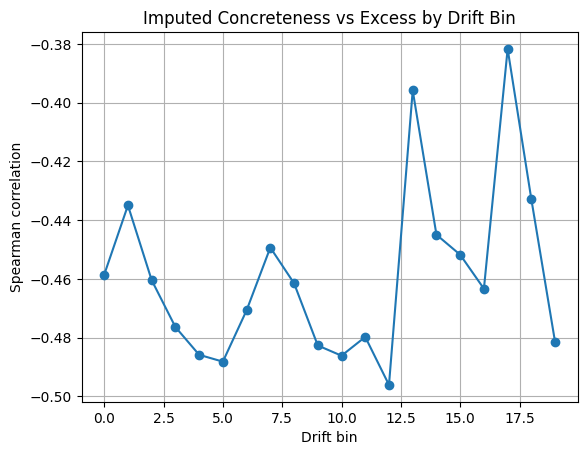

In [28]:
bin_keys = sorted(binned_dict.keys())
xs = bin_keys
ys = []

for bin_key in bin_keys:
    words = [item[0] for item in binned_dict[bin_key]]
    paired = [
        (imputed_concreteness[word], excess[word])
        for word in words
        if word in imputed_concreteness and word in excess
    ]

    if len(paired) >= 2:
        bin_xs, bin_ys = zip(*paired)
        ys.append(spearmanr(bin_xs, bin_ys).statistic)
    else:
        ys.append(np.nan)

plt.plot(xs, ys, marker="o")
plt.xlabel("Drift bin")
plt.ylabel("Spearman correlation")
plt.title("Imputed Concreteness vs Excess by Drift Bin")
plt.grid(True)
plt.show()

There is no trend between the correlation of imputed concreteness against excess and drift bin. I tried the same graph using Brysbaert's ratings to ensure the imputed values weren't adding extra noise. 

In [29]:
print(len([word for word in sp.words[2012] if word in dp and word in excess and word in sp.words[2014]]))

40888


 drift_bin    n  spearman
         0 1317     0.047
         1 1376     0.085
         2 1354     0.020
         3 1356    -0.008
         4 1249    -0.043
         5 1132     0.037
         6 1174    -0.057
         7 1077    -0.056
         8 1036    -0.047
         9  973    -0.044
        10  933    -0.033
        11  894    -0.066
        12  926    -0.013
        13  897     0.058
        14  841     0.031
        15  827    -0.037
        16  799     0.040
        17  748     0.067
        18  679     0.036
        19  563     0.126


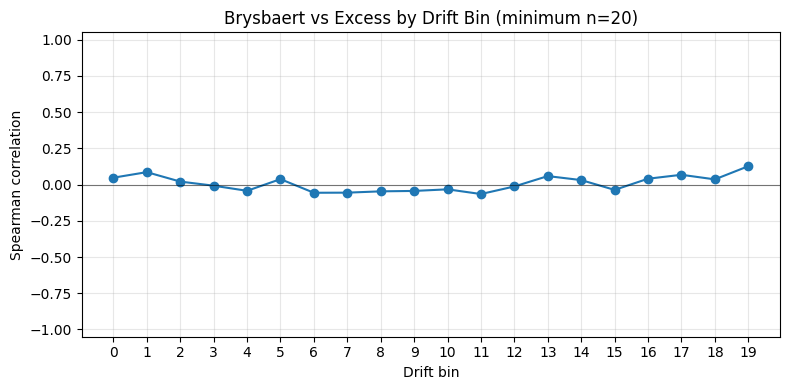

In [30]:
bin_keys = sorted(binned_dict.keys())
min_n = 20

xs, ys, ns = [], [], []

for bin_key in bin_keys:
    words = binned_dict[bin_key]
    paired = [
        (brysbaert.loc[word, "Conc.M"], excess[word])
        for word in words
        if word in brysbaert.index and word in excess
    ]

    if len(paired) >= min_n:
        bin_xs, bin_ys = zip(*paired)
        correlation = spearmanr(bin_xs, bin_ys).statistic
        if np.isfinite(correlation):
            xs.append(bin_key)
            ys.append(correlation)
            ns.append(len(paired))

print(pd.DataFrame({"drift_bin": xs, "n": ns, "spearman": ys}).round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, ys, marker="o")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Drift bin")
ax.set_ylabel("Spearman correlation")
ax.set_title(f"Brysbaert vs Excess by Drift Bin (minimum n={min_n})")
ax.set_xticks(xs)
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

There is even less of a correlation between Brysbart and excess across drift bins.

I then isolated the corelation by part of speech to fully test the hypothesis. I used sense tags from WordNet. 

In [31]:
from collections import defaultdict
from nltk.corpus import wordnet as wn

def word_pos(word):
    tags = {sense.pos() for sense in wn.synsets(word)}
    if "n" in tags:
        return "noun"
    if "v" in tags:
        return "verb"
    if "a" in tags or "s" in tags:
        return "adjective"
    if "r" in tags:
        return "adverb"
    return "unknown"

pos_by_word = {word: word_pos(word) for word in keys}
imputed_by_word = {
    word: float(np.asarray(score).squeeze())
    for word, score in imputed_concreteness.items()
}

min_n = 20
pos_results = defaultdict(lambda: {"bin": [], "correlation": [], "n": []})

for bin_key in sorted(binned_dict):
    for pos in ["noun", "verb", "adjective", "adverb"]:
        paired = [
            (imputed_by_word[word], excess[word])
            for word in binned_dict[bin_key]
            if pos_by_word.get(word) == pos and word in imputed_by_word and word in excess
        ]

        if len(paired) >= min_n:
            concreteness, excess_values = zip(*paired)
            correlation = spearmanr(concreteness, excess_values).statistic

            if np.isfinite(correlation):
                pos_results[pos]["bin"].append(bin_key)
                pos_results[pos]["correlation"].append(correlation)
                pos_results[pos]["n"].append(len(paired))

In [32]:
import plotly.graph_objects as go

imputed_by_word = {
    word: float(np.asarray(score).squeeze())
    for word, score in imputed_concreteness.items()
}

pos_names = [pos for pos in ["noun", "verb", "adjective", "adverb"] if pos in pos_results]
colors = {"noun": "#1f77b4", "verb": "#ff7f0e", "adjective": "#2ca02c", "adverb": "#d62728"}

fig = go.Figure()

for pos in pos_names:
    result = pos_results[pos]
    fig.add_trace(go.Scatter(
        x=result["bin"],
        y=result["correlation"],
        customdata=result["n"],
        mode="lines+markers",
        name=pos,
        line={"color": colors[pos], "width": 2},
        marker={"size": 7},
        hovertemplate=(
            f"POS: {pos}<br>"
            "Drift bin: %{x}<br>"
            "Spearman: %{y:.3f}<br>"
            "n: %{customdata}<extra></extra>"
        ),
    ))

buttons = [{
    "label": "All",
    "method": "update",
    "args": [{"opacity": [1] * len(pos_names), "line.width": [2] * len(pos_names)}],
}]

for selected_pos in pos_names:
    buttons.append({
        "label": selected_pos,
        "method": "update",
        "args": [{
            "opacity": [1 if pos == selected_pos else 0.2 for pos in pos_names],
            "line.width": [3 if pos == selected_pos else 1 for pos in pos_names],
        }],
    })

fig.update_layout(
    title=f"Imputed Concreteness vs Excess by POS and Drift Bin (minimum n={min_n})",
    xaxis_title="Drift bin",
    yaxis_title="Spearman correlation",
    yaxis={"range": [-1.05, 1.05]},
    hovermode="closest",
    template="plotly_white",
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "showactive": True,
        "x": 1.0,
        "xanchor": "right",
        "y": 1.15,
        "yanchor": "top",
    }],
)

fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="gray")
fig.show()

Again, there doesn't seem to be a correlation between imputed concreteness and excess across drift bins. Nouns show the least correlation across all bins and the lowest trend generally. Adverbs display a slight increasing trend, but the dips in the middle weaken the strength of any overall trend. However, there could still be a difference generally between the POS. 

In [33]:
from scipy.stats import kruskal, rankdata, mannwhitneyu

ws = sorted(excess)
part_tags = np.array([word_pos(word) for word in ws])
excess_values = np.array([excess[word] for word in ws])

log_frequency = np.log10([sum(counts[word].get(y, 0) for y in sp.years) for word in ws])

groups = [excess_values[part_tags == pos] for pos in ["noun", "verb", "adjective", "adverb"]]
h = kruskal(*groups)
print(h)

m = (part_tags == "noun") | (part_tags == "adverb")
x, y = (part_tags[m] == "noun").astype(float), excess_values[m]

u = mannwhitneyu(y[x == 1], y[x == 0], alternative="two-sided")
print(f"Mann-Whitney U test for noun vs adverb: U={u.statistic}, p={u.pvalue}")


def partial_spearman(x, y, z):
    rx, ry, rz = rankdata(x), rankdata(y), rankdata(z)
    res = lambda r: r - np.polyval(np.polyfit(rz, r, 1), rz)
    return spearmanr(res(rx), res(ry)).statistic


print("controlling for log frequency:", partial_spearman(x, y, log_frequency[m]))


KruskalResult(statistic=np.float64(141.64609515255557), pvalue=np.float64(1.6692363639492787e-30))
Mann-Whitney U test for noun vs adverb: U=13313697.5, p=5.608671682753279e-13
controlling for log frequency: 0.07401300992650682


In [34]:
n, k = sum(len(g) for g in groups), len(groups)
print(f"n={n}  k={k}")
print("eps^2={:.5f}".format((h.statistic - k + 1) / (n - k)))


n=33196  k=4
eps^2=0.00418


I used Kruskal-Wallis to determine whether there was separation between the groups. The tiny p-value suggests there was some difference in between groups; however, $\epsilon^2=0.0042$ means the groups only confer a tiny amount of variance. I used Mann-Whitney to test nouns vs. adverbs directly. Again, the p-value was small enough to reject the null hypothesis: nouns move slightly straighter than adverbs.

In [35]:
conc_mask = np.array([w in imputed_concreteness for w in ws])
conc = np.array([float(np.asarray(imputed_concreteness[w]).squeeze())
                 for w in np.array(ws)[conc_mask]])
exc_c, logf_c = excess_values[conc_mask], log_frequency[conc_mask]

print(f"n = {len(conc)}")
print("concreteness ~ excess:            ", spearmanr(conc, exc_c).statistic)
print("  controlling log frequency:      ", partial_spearman(conc, exc_c, logf_c))
print("excess ~ log frequency:           ", spearmanr(exc_c, logf_c).statistic)

deciles = np.digitize(logf_c, np.percentile(logf_c, np.arange(10, 100, 10)))
for d in range(10):
    s = deciles == d
    print(f"  decile {d}: rho={spearmanr(conc[s], exc_c[s]).statistic:+.4f}  n={s.sum():5d}")

n = 40888
concreteness ~ excess:             -0.030420912532882677
  controlling log frequency:       0.006355662073322247
excess ~ log frequency:            0.5383744610171467
  decile 0: rho=+0.0010  n= 4089
  decile 1: rho=-0.0251  n= 4086
  decile 2: rho=-0.0454  n= 4092
  decile 3: rho=-0.0511  n= 4088
  decile 4: rho=-0.0715  n= 4089
  decile 5: rho=-0.0649  n= 4088
  decile 6: rho=-0.0083  n= 4088
  decile 7: rho=+0.0717  n= 4090
  decile 8: rho=+0.1751  n= 4089
  decile 9: rho=+0.1004  n= 4089


## Conclusion 

In conclusion, descriptive content, measured through imputed concreteness values based on Brysbaert et al's published values, does not correlate with excess directional persistence in nouns or any other part of speech. Additionally, POS explains only 0.4% of variance in excess, and what separation exists suggests that nouns move straighter than adverbs, backwards from Hamilton's claim. Both metrics are rooted in the embedding space, meaning they may measure vector stability more than bleaching. Future work could use sentence position to eliminate this concern and provide concreteness rankings using feature engineering on the imputed concreteness model or using a non-geometric measure entirely. 